# **Chapter3: Convolutional Neural Networks (CNNs)**

This chapter introduces Convolutional Neural Networks in a step-by-step style similar to the earlier chapters. We explain the main ideas, use diagrams to build intuition, and then train a practical PyTorch example on image data.


## **Setup and data preparation**

To keep the notebook easy to run locally, this chapter uses the handwritten digits dataset from `sklearn`. The dataset is small, well structured, and very useful for demonstrating how a CNN learns from image data.


In [16]:
# Required modules

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
torch.manual_seed(42)
np.random.seed(42)


## **What is a Convolutional Neural Network?**


A **Convolutional Neural Network (CNN)** is a type of neural network that is especially effective for image data. Instead of connecting every pixel directly to every neuron at the start, a CNN learns small filters that move across the image and search for useful local patterns such as **edges, corners, curves, and textures**. As the network becomes deeper, those simple patterns are combined into more meaningful visual features.


## **Why CNNs are useful for images**


CNNs are particularly powerful for images because they preserve the **spatial structure** of the input. A CNN first learns local patterns, then gradually combines those patterns into larger and more complex shapes. Because the same filter is reused across many positions, CNNs are also more efficient than a fully connected network for image tasks. For this reason, CNNs are widely used in **image classification, object detection, segmentation, and facial recognition**.


## **Key building blocks of a CNN**


**1. Convolution layer**

A convolution layer applies a small matrix called a **kernel** or **filter** to local regions of the image. Each filter creates a **feature map** that responds strongly when a useful pattern is found.

**2. Activation function**

After convolution, we usually apply a non-linear activation such as **ReLU**. This helps the network learn patterns that are more complex than simple linear relationships.

**3. Pooling layer**

Pooling reduces the spatial size of the feature map. This lowers computation, helps reduce noise, and keeps the most important information.

**4. Flatten and fully connected layer**

Near the end of the network, the feature maps are flattened into a vector and passed to dense layers for the final prediction.


## **Diagram: image, filter, and feature map**


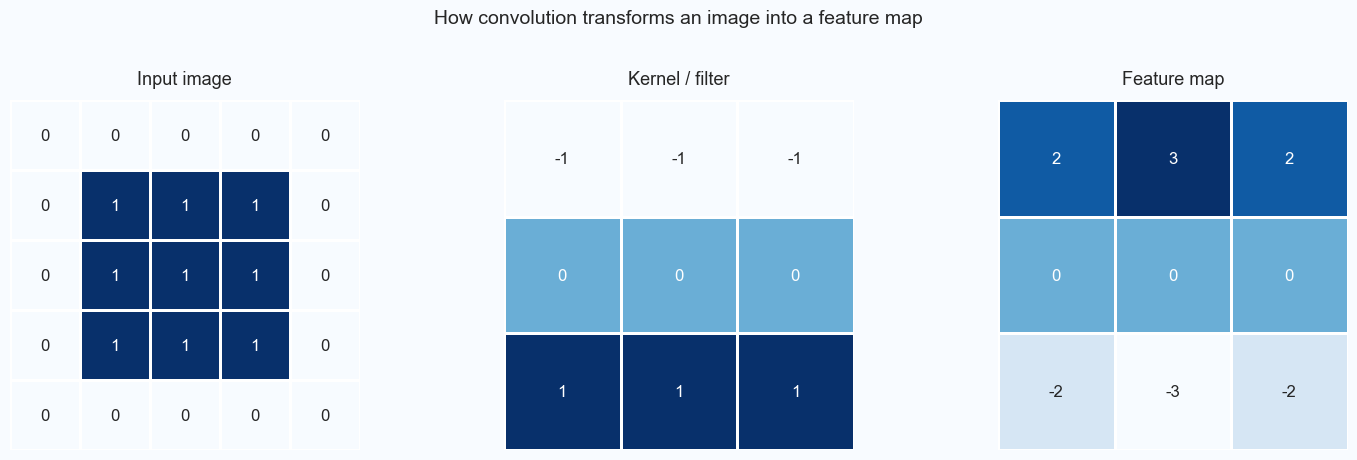

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor='#f8fbff')

image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
])

kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
])

input_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
kernel_tensor = torch.tensor(kernel, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
feature_map = F.conv2d(input_tensor, kernel_tensor).squeeze().numpy()

for ax, arr, title in zip(
    axes,
    [image, kernel, feature_map],
    ['Input image', 'Kernel / filter', 'Feature map'],
):
    sns.heatmap(arr, annot=True, cmap='Blues', cbar=False, square=True, linewidths=1, linecolor='white', ax=ax)
    ax.set_title(title, pad=12)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('How convolution transforms an image into a feature map', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


The filter slides across the image and computes local weighted sums. Where the pattern in the image matches the filter, the response becomes stronger. That is the main intuition behind a **feature map**.


## **Important CNN terms**


- **Kernel / filter**: the small matrix that scans the image.
- **Stride**: how many pixels the filter moves at a time.
- **Padding**: extra border values added so the output does not shrink too quickly.
- **Feature map**: the output produced by a filter after scanning the image.
- **Channel**: a separate layer of image information, such as grayscale or RGB.


## **Diagram: stride and padding intuition**


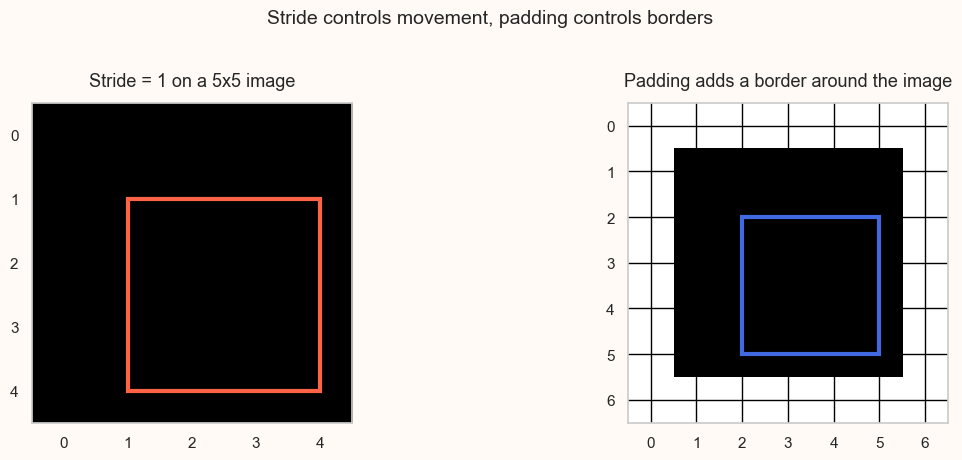

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#fffaf5')

axes[0].imshow(np.ones((5, 5)), cmap='Greys', vmin=0, vmax=1)
rect1 = plt.Rectangle((1, 1), 3, 3, fill=False, edgecolor='tomato', linewidth=3)
axes[0].add_patch(rect1)
axes[0].set_title('Stride = 1 on a 5x5 image', pad=12)
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))
axes[0].grid(color='black', linewidth=1)

padded = np.pad(np.ones((5, 5)), pad_width=1)
axes[1].imshow(padded, cmap='Greys', vmin=0, vmax=1)
rect2 = plt.Rectangle((2, 2), 3, 3, fill=False, edgecolor='royalblue', linewidth=3)
axes[1].add_patch(rect2)
axes[1].set_title('Padding adds a border around the image', pad=12)
axes[1].set_xticks(range(7))
axes[1].set_yticks(range(7))
axes[1].grid(color='black', linewidth=1)

fig.suptitle('Stride controls movement, padding controls borders', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Stride** controls how quickly the filter moves, while **padding** controls what happens at the borders of the image. These choices influence the output size and determine how much detail is preserved.


## **Pooling**


Pooling summarizes nearby values. The most common option is **max pooling**, which keeps the largest value in a local window and discards the rest.


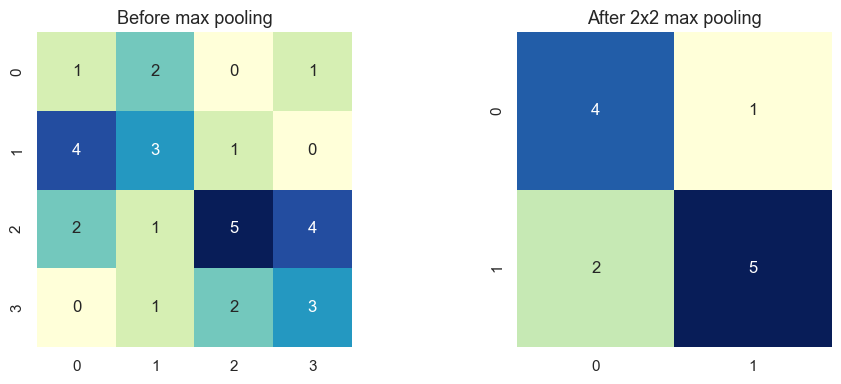

In [19]:
feature_map = torch.tensor([
    [1, 2, 0, 1],
    [4, 3, 1, 0],
    [2, 1, 5, 4],
    [0, 1, 2, 3],
], dtype=torch.float32)

pooled = F.max_pool2d(feature_map.unsqueeze(0).unsqueeze(0), kernel_size=2, stride=2).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(feature_map.numpy(), annot=True, cmap='YlGnBu', cbar=False, square=True, ax=axes[0])
axes[0].set_title('Before max pooling')
sns.heatmap(pooled, annot=True, cmap='YlGnBu', cbar=False, square=True, ax=axes[1])
axes[1].set_title('After 2x2 max pooling')
plt.tight_layout()
plt.show()


Pooling reduces the spatial dimensions of the feature map while keeping strong responses. This lowers computation and often improves robustness to small changes in the image.


## **Typical CNN pipeline**


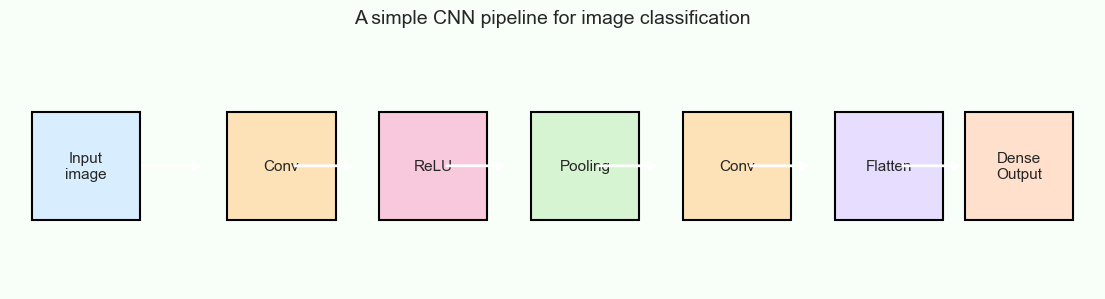

In [20]:
fig, ax = plt.subplots(figsize=(14, 3.2), facecolor='#f7fff8')
ax.axis('off')

blocks = [
    ('Input\nimage', 0.02, '#d8eefe'),
    ('Conv', 0.20, '#fde2b8'),
    ('ReLU', 0.34, '#f8c8dc'),
    ('Pooling', 0.48, '#d7f4d2'),
    ('Conv', 0.62, '#fde2b8'),
    ('Flatten', 0.76, '#e6ddff'),
    ('Dense\nOutput', 0.88, '#ffe0cc'),
]

for label, x, color in blocks:
    rect = plt.Rectangle((x, 0.28), 0.1, 0.44, facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.05, 0.5, label, ha='center', va='center', fontsize=11)

for x in [0.12, 0.26, 0.40, 0.54, 0.68, 0.82]:
    ax.annotate('', xy=(x + 0.06, 0.5), xytext=(x, 0.5), arrowprops=dict(arrowstyle='->', lw=2))

ax.set_title('A simple CNN pipeline for image classification', fontsize=14, pad=14)
plt.show()


A CNN usually stacks several convolution blocks before moving to dense layers for classification. Early layers detect simple visual cues such as edges, while deeper layers combine them into richer and more meaningful shapes.


## **Example 1: A hand-crafted edge detector**


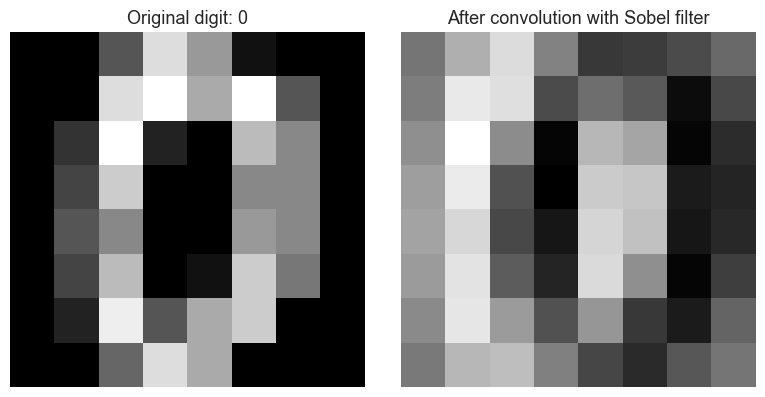

In [21]:
digits = load_digits()
images = digits.images
targets = digits.target

sample_image = images[0]
sobel_x = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=torch.float32)

sample_tensor = torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
edge_map = F.conv2d(sample_tensor, sobel_x.unsqueeze(0).unsqueeze(0), padding=1).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title(f'Original digit: {targets[0]}')
axes[0].axis('off')
axes[1].imshow(edge_map, cmap='gray')
axes[1].set_title('After convolution with Sobel filter')
axes[1].axis('off')
plt.tight_layout()
plt.show()


This example provides a simple intuition for convolution. The filter emphasizes one visual property, but in a real CNN the filters are **not hand-crafted**. They are learned automatically from the training data.


## **Prepare the dataset for a CNN**

The `digits` dataset contains small grayscale images of handwritten numbers from `0` to `9`. Because the images are already numeric and compact, the dataset is ideal for an introductory CNN example.


In [ ]:
digits = load_digits()
X = digits.images / 16.0
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(X_train_tensor.shape)
print(X_test_tensor.shape)


## **Preview some training images**

Before training the model, it is useful to inspect a few examples so we can understand the visual structure of the data.


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(f'Label: {y_train[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## **Define a simple CNN in PyTorch**

The model below uses two convolution blocks followed by a small classifier. This is a compact architecture, but it already demonstrates the standard CNN workflow.


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 2 * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)


## **Train the CNN**

Because the dataset is fairly small, we can train a compact CNN for a modest number of epochs and still obtain a useful result.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
patience = 8
min_delta = 1e-4


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=30, patience=8, min_delta=1e-4):
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    wait = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images_batch, labels_batch in train_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()
            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels_batch.size(0)
            train_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
            train_total += labels_batch.size(0)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images_batch, labels_batch in val_loader:
                images_batch = images_batch.to(device)
                labels_batch = labels_batch.to(device)
                outputs = model(images_batch)
                loss = criterion(outputs, labels_batch)

                val_loss += loss.item() * labels_batch.size(0)
                val_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
                val_total += labels_batch.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['loss'].append(epoch_train_loss)
        history['accuracy'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        print(
            f"Epoch {epoch + 1:02d} | "
            f"train_loss={epoch_train_loss:.4f} | train_acc={epoch_train_acc:.4f} | "
            f"val_loss={epoch_val_loss:.4f} | val_acc={epoch_val_acc:.4f}"
        )

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch + 1}')
                break

    model.load_state_dict(best_state)
    return history

history = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs=30,
    patience=patience,
    min_delta=min_delta,
)


## **Training and validation accuracy plot**


In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, acc, label='Training accuracy', color='darkorange')
plt.plot(epochs, val_acc, label='Validation accuracy', color='royalblue')
plt.title('CNN training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## **Model evaluation**

After training, we evaluate the CNN on unseen test images to measure how well it generalizes.


In [ ]:
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor.to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()

accuracy = accuracy_score(y_test, y_pred)
print(f'CNN accuracy on test data: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))


## **Confusion matrix**


In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


## **Example 2: Inspect some predictions**

Looking at individual predictions helps connect the accuracy score to actual model behaviour.


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f'True: {y_test[idx]} | Pred: {y_pred[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## **When should you use a CNN?**

A CNN is usually a strong choice when the input has clear **spatial structure**, especially images. CNNs remain excellent baseline models for image classification problems and are often preferred when local visual patterns matter more than isolated scalar features.


- Use a CNN when your input has **spatial structure**, especially images.
- CNNs are a strong baseline for **classification** problems on small and medium image datasets.
- They are especially useful when local patterns matter more than isolated features.


In this chapter, you learned that:

- CNNs process images through **convolutions** rather than only dense connections.
- Filters create **feature maps** that highlight useful patterns.
- **Stride, padding, and pooling** control how information moves through the network.
- A simple PyTorch CNN can already perform well on an introductory image-classification task.


In this chapter, you learned that:

- CNNs process images using **convolutions** rather than only dense connections.
- Filters produce **feature maps** that highlight useful patterns.
- **Stride, padding, and pooling** control how information flows through the network.
- PyTorch makes it straightforward to build and train a CNN for image classification.
